In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

In [4]:
data = pd.read_csv(r"E:\lebika_training\Housing.csv")

# Separate features and target variable
target = "price"
X = data.drop(columns=[target])
y = data[target]



X = X.replace(
    {
        "yes": 1,
        "no": 0,
        "furnished": 2,
        "semi-furnished": 1,
        "unfurnished": 0,
    }
)


X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


model = LinearRegression()
model.fit(X_train_scaled, y_train)


train_predictions = model.predict(X_train_scaled)
val_predictions = model.predict(X_val_scaled)
test_predictions = model.predict(X_test_scaled)



train_mse = mean_squared_error(y_train, train_predictions)
train_rmse = np.sqrt(train_mse)


# Metrics for Validation Data
val_mse = mean_squared_error(y_val, val_predictions)
val_rmse = np.sqrt(val_mse)


# Metrics for Test Data
test_mse = mean_squared_error(y_test, test_predictions)
test_rmse = np.sqrt(test_mse)



print("--- TRAINING SET PERFORMANCE ---")
print("RMSE:", train_rmse)

print()

print("--- VALIDATION SET PERFORMANCE ---")
print("RMSE:", val_rmse)

print()



--- TRAINING SET PERFORMANCE ---
RMSE: 951860.3605230264

--- VALIDATION SET PERFORMANCE ---
RMSE: 1227732.321016097



In [5]:

user_area = input("Enter house area ")
user_area = float(user_area)

user_bedrooms = input("Enter number of bedrooms ")
user_bedrooms = float(user_bedrooms)


new_house = [0] * len(X.columns)


new_house[0] = user_area
new_house[1] = user_bedrooms


new_house_scaled = scaler.transform([new_house])
predicted_price = model.predict(new_house_scaled)

print()
print("Estimated House Price:", round(predicted_price[0], 2))


Estimated House Price: 1306802.79


c:\Users\ADS2609024\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Correlation with house price:
price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64


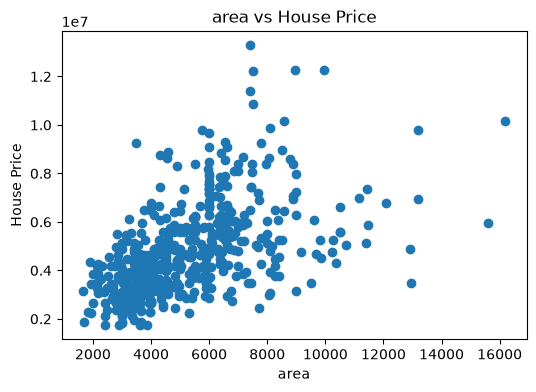

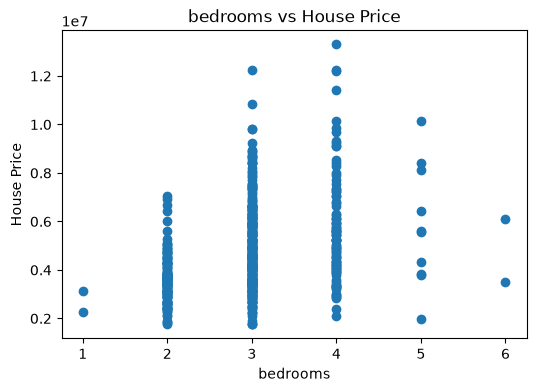

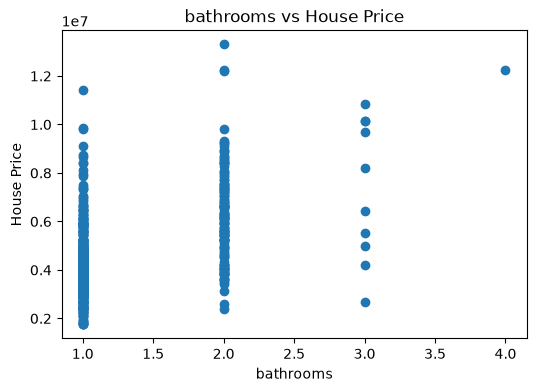

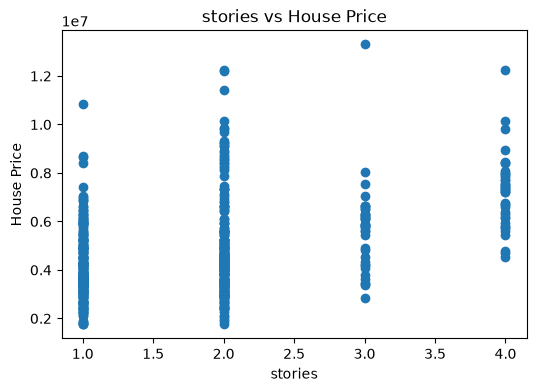

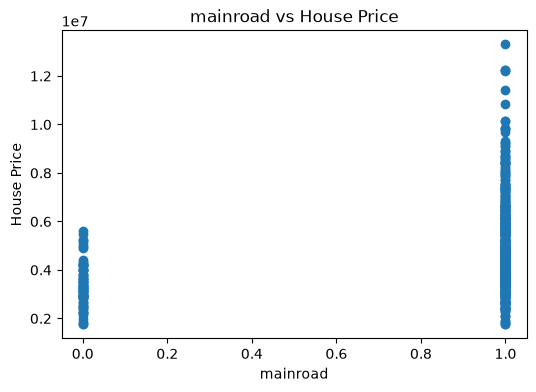

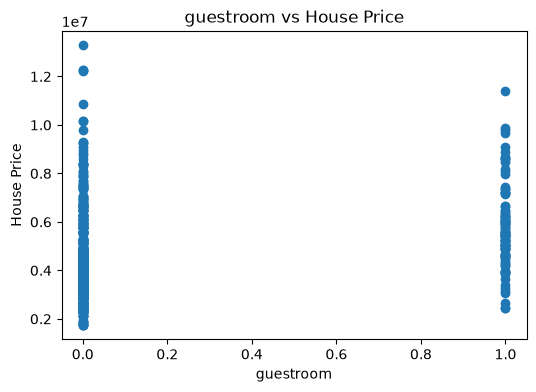

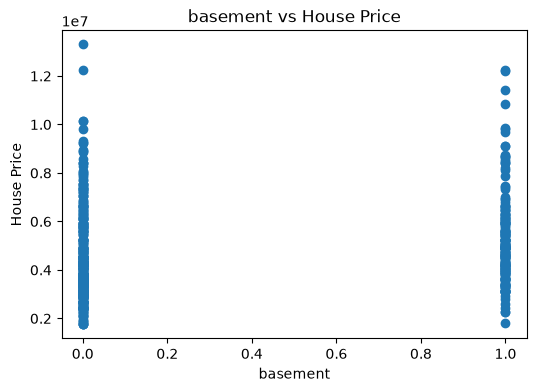

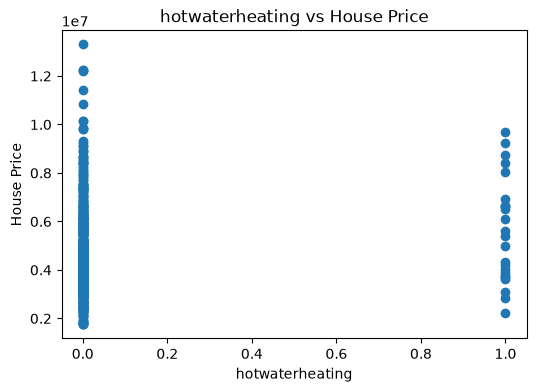

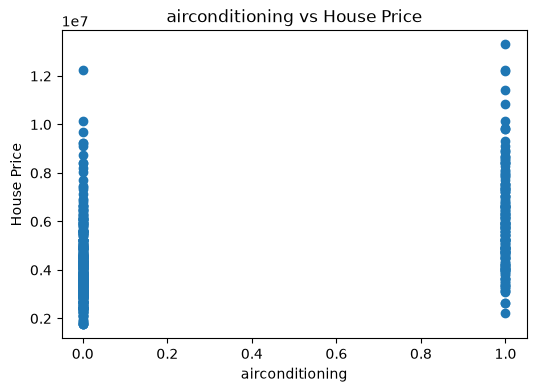

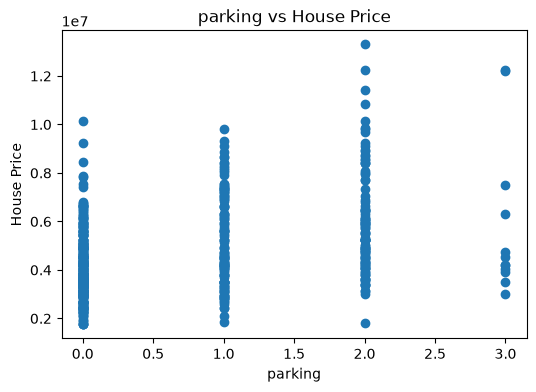

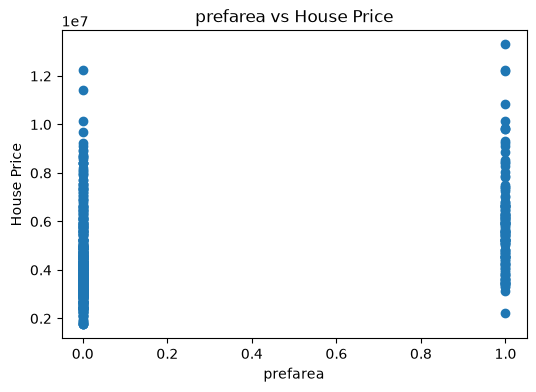

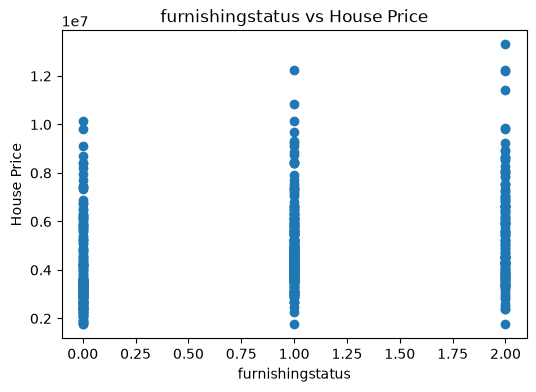

In [6]:


correlation = data.corr(numeric_only=True)

print("\nCorrelation with house price:")
print(
    correlation[target]
    .sort_values(ascending=False)
)


for feature in X.columns:

    plt.figure(figsize=(6, 4))

    plt.scatter(X[feature], y)

    plt.xlabel(feature)
    plt.ylabel("House Price")

    plt.title(feature + " vs House Price")



In [9]:

#GRADIENT DESCENT & NORMAL EQUATION 

import time

y_train_arr = y_train.values


N_train = len(y_train_arr)
ones_train = np.ones((N_train, 1))
X_train_matrix = np.hstack([ones_train, X_train_scaled])


num_parameters = X_train_matrix.shape[1]

#for cost function
cost_history = []

start_gd = time.time()

weights_gd = np.zeros(num_parameters)

learning_rate = 0.01
epochs = 1000


for i in range(epochs):
  
    predictions_gd = np.dot(X_train_matrix, weights_gd)
    
  
    error_gd = predictions_gd - y_train_arr

    #for cost function
    cost = (1 / N_train) * np.sum(error_gd**2)
    cost_history.append(cost)
    
    gradient_gd = (2 / N_train) * np.dot(X_train_matrix.T, error_gd)
    
    
    weights_gd = weights_gd - (learning_rate * gradient_gd)
end_gd = time.time()
time_gd = end_gd - start_gd 



start_normal = time.time()

XT_X = np.dot(X_train_matrix.T, X_train_matrix)
XT_X_inverse = np.linalg.inv(XT_X)
XT_y = np.dot(X_train_matrix.T, y_train_arr)

weights_normal = np.dot(XT_X_inverse, XT_y)

end_normal = time.time()
time_normal = end_normal - start_normal 


user_input_scaled_row = new_house_scaled[0]
user_vector_all_features = np.insert(user_input_scaled_row, 0, 1.0)



price_scratch_gd = np.dot(user_vector_all_features, weights_gd)
price_scratch_normal = np.dot(user_vector_all_features, weights_normal)



print()
print("--- SCRATCH PERFORMANCE (ALL FEATURES) ---")
print("Total Weights Learned    :", len(weights_normal))
print("Gradient Descent Price   :", round(price_scratch_gd, 2))
print("Normal Equation Price    :", round(price_scratch_normal, 2))
print("Scikit-Learn Model Price :", round(predicted_price[0], 2))

print()


print("WEIGHT COMPARISON")



comparison = pd.DataFrame(
    {"Gradient Descent": weights_gd, "Normal Equation": weights_normal}
)


feature_names = ["Intercept"] + list(X.columns)
comparison.index = feature_names


print(comparison.round(2))


print()

print("TIME COMPARISON")



print("Gradient Descent time:", round(time_gd, 6), "seconds")
print("Normal Equation time :", round(time_normal, 6), "seconds")



--- SCRATCH PERFORMANCE (ALL FEATURES) ---
Total Weights Learned    : 13
Gradient Descent Price   : 1306911.02
Normal Equation Price    : 1306802.79
Scikit-Learn Model Price : 1306802.79

WEIGHT COMPARISON
                  Gradient Descent  Normal Equation
Intercept               4598024.27       4598024.28
area                     510657.17        510695.69
bedrooms                  78076.30         78028.82
bathrooms                405740.53        405728.12
stories                  318040.47        318123.34
mainroad                 135862.26        135837.77
guestroom                132609.35        132566.00
basement                 198483.06        198553.00
hotwaterheating          164352.05        164341.16
airconditioning          300197.10        300161.75
parking                  210986.01        211000.47
prefarea                 189799.86        189790.96
furnishingstatus         186594.36        186588.05

TIME COMPARISON
Gradient Descent time: 0.026262 seconds
Normal E

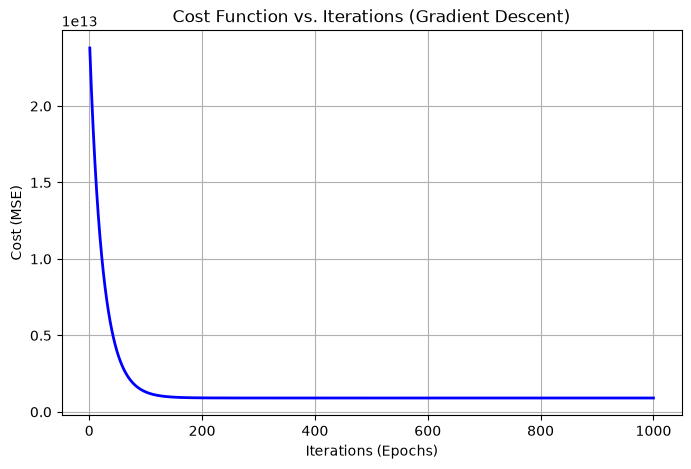

In [10]:


plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), cost_history, color="blue", linewidth=2)
plt.title("Cost Function vs. Iterations (Gradient Descent)")
plt.xlabel("Iterations (Epochs)")
plt.ylabel("Cost (MSE)")
plt.grid(True)
plt.show()

In [14]:

degrees = [1, 2, 3, 5]
train_mses = []
val_mses = []

print("POLYNOMIAL DEGREE EVALUATION ")
for degree in degrees:
    # Transform features for train and validation
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_val_poly = poly.transform(X_val_scaled)

    # Fit linear model on transformed features
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)

    # Predict
    y_train_pred = poly_model.predict(X_train_poly)
    y_val_pred = poly_model.predict(X_val_poly)

    # Calculate MSE and RMSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)

    train_mses.append(train_mse)
    val_mses.append(val_mse)

    print(
        f"Degree {degree:2d} | Train RMSE: {np.sqrt(train_mse):,.2f} | Val RMSE: {np.sqrt(val_mse):,.2f}"
    )

POLYNOMIAL DEGREE EVALUATION 
Degree  1 | Train RMSE: 951,860.36 | Val RMSE: 1,227,732.32
Degree  2 | Train RMSE: 708,722.90 | Val RMSE: 1,329,338.61
Degree  3 | Train RMSE: 176,483.38 | Val RMSE: 1,066,794,948.61
Degree  5 | Train RMSE: 111,742.98 | Val RMSE: 94,014,124.58


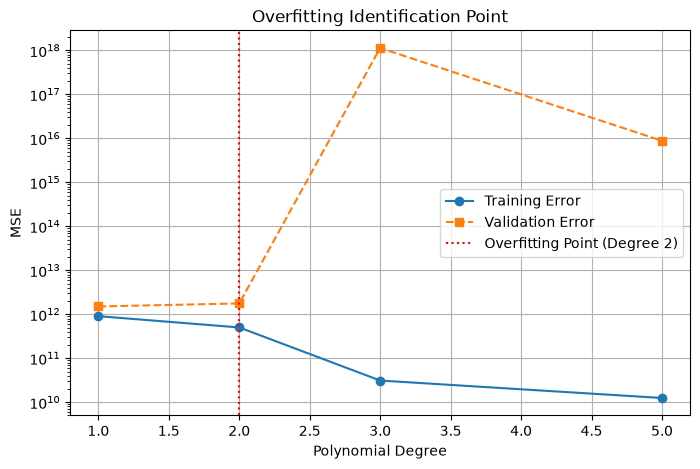

In [15]:

overfitting_degree = degrees[
    next(
        i
        for i in range(1, len(degrees))
        if val_mses[i] > val_mses[i - 1] and train_mses[i] < train_mses[i - 1]
    )
]

plt.figure(figsize=(8, 5))
plt.plot(degrees, train_mses, marker="o", label="Training Error")
plt.plot(degrees, val_mses, marker="s", linestyle="--", label="Validation Error")
plt.axvline(
    x=overfitting_degree,
    color="red",
    linestyle=":",
    label=f"Overfitting Point (Degree {overfitting_degree})",
)
plt.yscale("log")
plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Overfitting Identification Point")
plt.legend()
plt.grid(True)
plt.show()

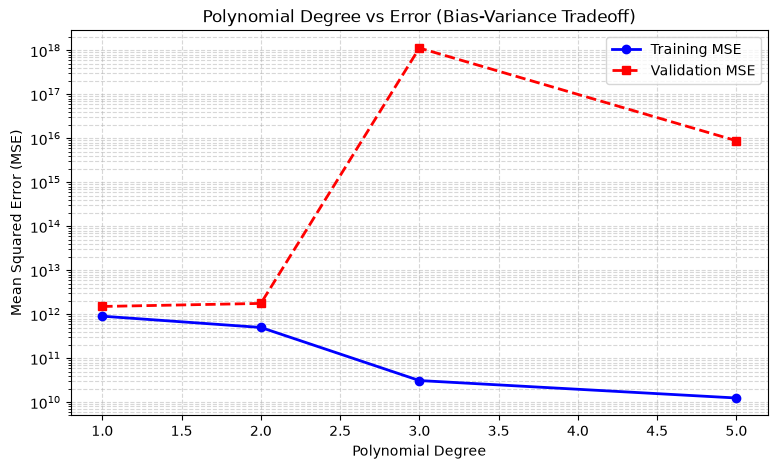

In [ ]:

plt.figure(figsize=(9, 5))
plt.plot(
    degrees,
    train_mses,
    marker="o",
    color="blue",
    linewidth=2,
    label="Training MSE",
)
plt.plot(
    degrees,
    val_mses,
    marker="s",
    color="red",
    linewidth=2,
    linestyle="--",
    label="Validation MSE",
)

plt.title("Polynomial Degree vs Error (Bias-Variance Tradeoff)")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error (MSE)")
plt.yscale("log") 
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()

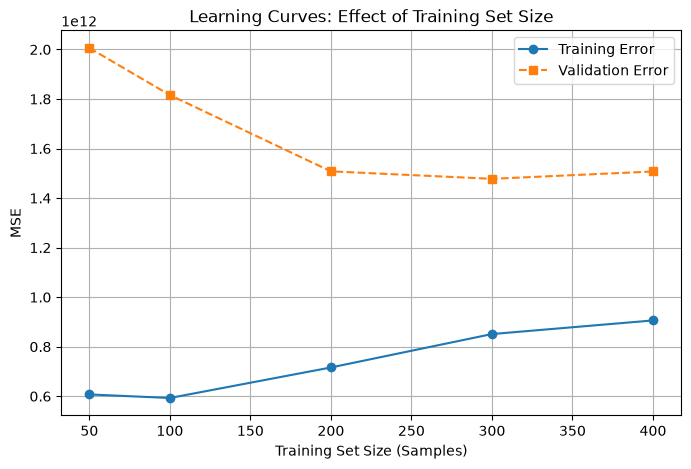

In [ ]:

train_sizes = [50, 100, 200, 300, 400]
train_errors_size = []
val_errors_size = []

for size in train_sizes:
    # Slice the training dataset
    X_sub = X_train_scaled[:size]
    y_sub = y_train[:size]

    
    sub_model = LinearRegression()
    sub_model.fit(X_sub, y_sub)

    # Predict & calculate MSE
    train_pred = sub_model.predict(X_sub)
    val_pred = sub_model.predict(X_val_scaled)

    train_errors_size.append(mean_squared_error(y_sub, train_pred))
    val_errors_size.append(mean_squared_error(y_val, val_pred))


plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_errors_size, marker="o", label="Training Error")
plt.plot(
    train_sizes,
    val_errors_size,
    marker="s",
    linestyle="--",
    label="Validation Error",
)
plt.xlabel("Training Set Size (Samples)")
plt.ylabel("MSE")
plt.title("Learning Curves: Effect of Training Set Size")
plt.legend()
plt.grid(True)
plt.show()